# Algorithm Sweep

Experiments on choosing indexing approach compared to Brute-force.

**Algorithms covered here (all via FAISS):**

| Class            | FAISS index         | Metric used         |
| ---------------- | ------------------- | ------------------- |
| Brute-force      | `IndexFlatIP`       | inner product       |
| IVF              | `IndexIVFFlat`      | inner product       |
| HNSW             | `IndexHNSWFlat`     | inner product       |
| NSG              | `IndexNSGFlat`      | inner product       |
| LSH              | `IndexLSH`          | Hamming (internal)  |
| Binary + IVF     | `IndexBinaryIVF`    | Hamming             |

All vectors are L2-normalized so inner product == cosine similarity.

## 1. Setup

In [12]:
import sys, time
from pathlib import Path

ROOT = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss

from indexing import NumpyFileSource

EMBEDS_PATH = ROOT / "data" / "wikipedia_embeddings_256d.npy"

# Fallback knobs.
FALLBACK_N = 20_000
FALLBACK_DIM = 768
FALLBACK_HIDDEN = 50

N_QUERIES = 200
TOPK = 10
print(f"faiss version: {faiss.__version__}")


faiss version: 1.14.3


## 2. Corpus, queries, ground truth

MockSource for now. The whole pipeline is agnostic to how vectors are
generated — swap in `NumpyFileSource(path)` when Person 2 delivers real
EmbeddingGemma embeddings.


In [13]:
def l2_normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)



src = NumpyFileSource(EMBEDS_PATH)
raw = np.asarray(src._vectors[:], dtype=np.float32)
print(f"real embeddings   : {EMBEDS_PATH}  N={raw.shape[0]:,}  dim={raw.shape[1]}")

N, DIM = raw.shape
corpus = l2_normalize(raw)

rng = np.random.default_rng(123)
qry_idx = rng.choice(N, size=N_QUERIES, replace=False)
queries = corpus[qry_idx].copy()

gt_index = faiss.IndexFlatIP(DIM)
gt_index.add(corpus)
_, gt = gt_index.search(queries, TOPK)
print(f"ground truth ready: {gt.shape}")


real embeddings   : /Users/tomatocoder/Desktop/local-wiki-rag/data/wikipedia_embeddings_256d.npy  N=500,000  dim=256
ground truth ready: (200, 10)


## 3. Reusable benchmark harness

One function that takes a built FAISS index and a list of `(label,
setter_fn)` param configurations. Same function used for **every** algorithm below.

In [14]:
def bench(idx, method_name, param_configs, queries, gt, topk,
          extra_meta=None, is_binary=False, binarizer=None):
    """Sweep param_configs on `idx`, return list of result rows."""
    rows = []
    q = binarizer(queries) if is_binary else queries
    for label, setter in param_configs:
        if setter is not None:
            setter(idx)

        _ = idx.search(q[:1], topk)
        t = time.perf_counter()
        _, labels = idx.search(q, topk)
        latency_ms = (time.perf_counter() - t) / len(q) * 1000

        hits = 0
        for i in range(len(labels)):
            hits += len(set(labels[i].tolist()) & set(gt[i].tolist()))
        recall = hits / (len(labels) * topk)

        row = {"method": method_name, "config": label,
               "recall@10": recall, "latency_ms": latency_ms}
        if extra_meta:
            row.update(extra_meta)
        rows.append(row)
    return rows


all_results = []


## 4. Brute force — `IndexFlatIP`

Sets the recall ceiling and the
latency floor for "exact" methods. Every approximate method is compared
against this.

In [15]:
idx_flat = faiss.IndexFlatIP(DIM)
t = time.perf_counter()
idx_flat.add(corpus)
flat_build = time.perf_counter() - t

rows = bench(idx_flat, "brute_force", [("exact", None)], queries, gt, TOPK,
             extra_meta={"build_s": round(flat_build, 3)})
all_results += rows
print(rows[0])


{'method': 'brute_force', 'config': 'exact', 'recall@10': 1.0, 'latency_ms': 4.008327914925758, 'build_s': 0.227}


## 5. IVF — `IndexIVFFlat`

Standard IVF: k-means centroids, inverted lists, `nprobe` at query time.


nlist basically should be `sqrt(N)` where `N` is the number of vectors in the index. So it's better to use for our corpus numbers like 512, 1024

In [17]:
nlists = [512, 1024]

In [19]:
middle_results = pd.DataFrame()

for nlist in nlists:
    quantizer = faiss.IndexFlatIP(DIM)
    idx_ivf = faiss.IndexIVFFlat(quantizer, DIM, nlist, faiss.METRIC_INNER_PRODUCT)
    t = time.perf_counter()
    idx_ivf.train(corpus)
    idx_ivf.add(corpus)
    ivf_build = time.perf_counter() - t

    def set_nprobe(n):
        return lambda idx: setattr(idx, "nprobe", n)

    configs = [(f"nprobe={n}", set_nprobe(n)) for n in [1, 2, 4, 8, 16, 32, 64]]
    rows = bench(idx_ivf, "ivf", configs, queries, gt, TOPK,
                extra_meta={"build_s": round(ivf_build, 3), "nlist": nlist})
    all_results += rows
    middle_results = pd.concat([middle_results, pd.DataFrame(rows)], ignore_index=True)

middle_results


,method,config,recall@10,latency_ms,build_s,nlist
0,ivf,nprobe=1,0.5595,0.011843,1.009,512
1,ivf,nprobe=2,0.7350,0.020190,1.009,512
2,ivf,nprobe=4,0.8645,0.036934,1.009,512
3,ivf,nprobe=8,0.9530,0.072172,1.009,512
4,ivf,nprobe=16,0.9875,0.165842,1.009,512
5,ivf,nprobe=32,0.9975,0.295332,1.009,512
6,ivf,nprobe=64,0.9985,0.515111,1.009,512
7,ivf,nprobe=1,0.5215,0.009009,2.249,1024
8,ivf,nprobe=2,0.6790,0.013866,2.249,1024
9,ivf,nprobe=4,0.8165,0.020573,2.249,1024


## Remark
For nprobe >= 16 recall is almost 1.0, however for nprobe=16 latency is already 10x faster for baseline

## 6. HNSW — `IndexHNSWFlat`

Graph-based, top of the ANN family for high recall. `M` is graph
degree (by default recommended as 32), `efConstruction` is build quality, `efSearch` is the runtime
knob.


In [21]:
M = 32
idx_hnsw = faiss.IndexHNSWFlat(DIM, M, faiss.METRIC_INNER_PRODUCT)
idx_hnsw.hnsw.efConstruction = 150
t = time.perf_counter()
idx_hnsw.add(corpus)
hnsw_build = time.perf_counter() - t

def set_ef(ef):
    return lambda idx: setattr(idx.hnsw, "efSearch", ef)

configs = [(f"efSearch={ef}", set_ef(ef)) for ef in [2, 32, 64, 128, 256, 512]]
rows = bench(idx_hnsw, "hnsw", configs, queries, gt, TOPK,
             extra_meta={"build_s": round(hnsw_build, 3), "M": M})
all_results += rows
pd.DataFrame(rows).round(3)


,method,config,recall@10,latency_ms,build_s,M
0,hnsw,efSearch=2,0.790,0.006,34.443,32
1,hnsw,efSearch=32,0.992,0.021,34.443,32
2,hnsw,efSearch=64,0.998,0.035,34.443,32
3,hnsw,efSearch=128,1.000,0.065,34.443,32
4,hnsw,efSearch=256,1.000,0.113,34.443,32
5,hnsw,efSearch=512,1.000,0.205,34.443,32


## Remark
for efSearch>=80 recall is high but latency is small (0.034) for efSearch=80. Build time is same for each hyperparam

## 7. NSG — `IndexNSGFlat`

Navigating Spreading-out Graph. Different graph
construction than HNSW; often competitive on well-clustered data. `R`
is graph degree, `search_L` is the runtime knob.


In [24]:
rs = [32, 64, 128]

In [25]:
m_res = pd.DataFrame()
for R in rs:
    idx_nsg = faiss.IndexNSGFlat(DIM, R, faiss.METRIC_INNER_PRODUCT)
    t = time.perf_counter()
    idx_nsg.add(corpus)
    nsg_build = time.perf_counter() - t

    def set_search_L(L):
        return lambda idx: setattr(idx.nsg, "search_L", L)

    configs = [(f"search_L={L}", set_search_L(L)) for L in [16, 32, 64, 128, 256]]
    rows = bench(idx_nsg, "nsg", configs, queries, gt, TOPK,
                extra_meta={"build_s": round(nsg_build, 3), "R": R})
    all_results += rows
    m_res = pd.concat([m_res, pd.DataFrame(rows)], ignore_index=True)
m_res

,method,config,recall@10,latency_ms,build_s,R
0,nsg,search_L=16,0.9670,0.032569,120.664,32
1,nsg,search_L=32,0.9830,0.033925,120.664,32
2,nsg,search_L=64,0.9920,0.057136,120.664,32
3,nsg,search_L=128,0.9985,0.096195,120.664,32
4,nsg,search_L=256,0.9985,0.157573,120.664,32
5,nsg,search_L=16,0.7180,0.041683,159.758,64
6,nsg,search_L=32,0.9950,0.043554,159.758,64
7,nsg,search_L=64,0.9990,0.096758,159.758,64
8,nsg,search_L=128,1.0000,0.149207,159.758,64
9,nsg,search_L=256,1.0000,0.191735,159.758,64


## Remark
Build time is significantly larger than for HNSW and for best recall (s_L=256) latency is 0.1. 

## 8. LSH — `IndexLSH`

Random-projection LSH. Number of bits is the main quality knob —
higher bits, higher recall, more memory. There's no runtime parameter

In [26]:
lsh_rows = []
for nbits in [256, 512, 1024]:
    idx_lsh = faiss.IndexLSH(DIM, nbits)
    t = time.perf_counter()
    idx_lsh.train(corpus)
    idx_lsh.add(corpus)
    lsh_build = time.perf_counter() - t
    r = bench(idx_lsh, "lsh", [(f"nbits={nbits}", None)], queries, gt, TOPK,
              extra_meta={"build_s": round(lsh_build, 3)})
    lsh_rows += r
all_results += lsh_rows
pd.DataFrame(lsh_rows).round(3)


,method,config,recall@10,latency_ms,build_s
0,lsh,nbits=256,0.072,0.122,0.293
1,lsh,nbits=512,0.149,0.171,0.359
2,lsh,nbits=1024,0.222,0.402,0.736


## 9. Binary + IVF — `IndexBinaryIVF`

Hamming embedding with a Voronoi partition on top. 

In [27]:
def make_binarizer(nbits, dim, seed=0):
    rng = np.random.default_rng(seed)
    R = rng.standard_normal((dim, nbits)).astype(np.float32)
    def binarize(X):
        bits = (X @ R) > 0                     # (N, nbits) bool
        # Pack into uint8 bytes (nbits must be % 8 == 0).
        return np.packbits(bits, axis=1).astype(np.uint8)
    return binarize


nbits_bin = 256
binarize = make_binarizer(nbits_bin, DIM, seed=0)
corpus_bin = binarize(corpus)                   # (N, nbits/8) uint8

print(corpus_bin[0], corpus_bin[0])

quantizer_bin = faiss.IndexBinaryFlat(nbits_bin)
idx_bin_ivf = faiss.IndexBinaryIVF(quantizer_bin, nbits_bin, 64)
t = time.perf_counter()
idx_bin_ivf.train(corpus_bin)
idx_bin_ivf.add(corpus_bin)
bin_build = time.perf_counter() - t

def set_bin_nprobe(n):
    return lambda idx: setattr(idx, "nprobe", n)

configs = [(f"bin_nprobe={n}", set_bin_nprobe(n)) for n in [1, 2, 4, 8, 16, 32]]
rows = bench(idx_bin_ivf, "binary_ivf", configs, queries, gt, TOPK,
             extra_meta={"build_s": round(bin_build, 3), "nbits": nbits_bin},
             is_binary=True, binarizer=binarize)
all_results += rows
pd.DataFrame(rows).round(3)


/var/folders/w3/4nl0r9vd1xl15fkg3mfm2ps80000gn/T/ipykernel_79288/257439431.py:5: RuntimeWarning: divide by zero encountered in matmul
  bits = (X @ R) > 0                     # (N, nbits) bool
/var/folders/w3/4nl0r9vd1xl15fkg3mfm2ps80000gn/T/ipykernel_79288/257439431.py:5: RuntimeWarning: overflow encountered in matmul
  bits = (X @ R) > 0                     # (N, nbits) bool
/var/folders/w3/4nl0r9vd1xl15fkg3mfm2ps80000gn/T/ipykernel_79288/257439431.py:5: RuntimeWarning: invalid value encountered in matmul
  bits = (X @ R) > 0                     # (N, nbits) bool


[ 97  55  89   7  13 208  12 203  73  70 162 190  22 140 124 241  70  80
  75 145  38 154 156  31  17  60 244 113 128 136  87 139] [ 97  55  89   7  13 208  12 203  73  70 162 190  22 140 124 241  70  80
  75 145  38 154 156  31  17  60 244 113 128 136  87 139]


,method,config,recall@10,latency_ms,build_s,nbits
0,binary_ivf,bin_nprobe=1,0.072,0.009,1.608,256
1,binary_ivf,bin_nprobe=2,0.072,0.010,1.608,256
2,binary_ivf,bin_nprobe=4,0.074,0.011,1.608,256
3,binary_ivf,bin_nprobe=8,0.074,0.024,1.608,256
4,binary_ivf,bin_nprobe=16,0.074,0.030,1.608,256
5,binary_ivf,bin_nprobe=32,0.074,0.051,1.608,256


## 10. Unified Pareto plot

All six algorithms on the same axes: `latency_ms` (log-scale, lower =
better) vs `recall@10` (higher = better). Points on the upper-left
front dominate.


saved 70 rows to indexing/experiments/faiss_benchmark.csv


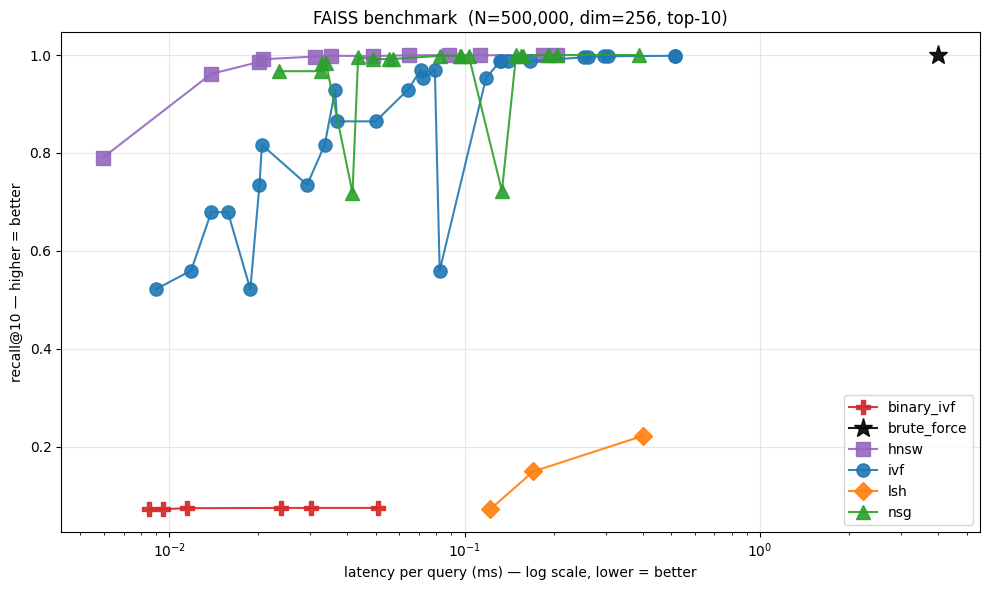

In [28]:
df = pd.DataFrame(all_results)
df.to_csv(ROOT / "indexing" / "experiments" / "faiss_benchmark.csv", index=False)
print(f"saved {len(df)} rows to indexing/experiments/faiss_benchmark.csv")

styles = {
    "brute_force":  {"marker": "*", "color": "black",       "size": 200},
    "ivf":          {"marker": "o", "color": "tab:blue",    "size": 90},
    "hnsw":         {"marker": "s", "color": "tab:purple",  "size": 90},
    "nsg":          {"marker": "^", "color": "tab:green",   "size": 90},
    "lsh":          {"marker": "D", "color": "tab:orange",  "size": 90},
    "binary_ivf":   {"marker": "P", "color": "tab:red",     "size": 90},
}

fig, ax = plt.subplots(figsize=(10, 6))
for method, sub in df.groupby("method"):
    sub = sub.sort_values("latency_ms")
    s = styles.get(method, {"marker": "o", "color": "grey", "size": 70})
    ax.plot(sub["latency_ms"], sub["recall@10"],
            marker=s["marker"], color=s["color"], label=method,
            linewidth=1.5, markersize=np.sqrt(s["size"]), alpha=0.9)

ax.set_xlabel("latency per query (ms) — log scale, lower = better")
ax.set_ylabel("recall@10 — higher = better")
ax.set_title(f"FAISS benchmark  (N={N:,}, dim={DIM}, top-{TOPK})")
ax.set_xscale("log")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 11. Summary table

In [29]:
summary = (
    df.groupby("method")
      .agg(
          best_recall=("recall@10", "max"),
          fastest_ms=("latency_ms", "min"),
          n_configs=("config", "count"),
          build_s=("build_s", "first"),
      )
      .round(3)
      .sort_values("best_recall", ascending=False)
)
summary


,best_recall,fastest_ms,n_configs,build_s
method,,,,
brute_force,1.000,4.008,1,0.227
hnsw,1.000,0.006,12,47.116
nsg,1.000,0.024,20,78.475
ivf,0.998,0.009,28,1.105
lsh,0.222,0.122,3,0.293
binary_ivf,0.074,0.009,6,1.608
